### **IMPORT LIBRARY**

In [ ]:
!pip install torchinfo

In [ ]:
import os
import hashlib
import copy
import time

import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as transforms
from torchvision import models

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

from google.colab import files
from torchinfo import summary

### **CLONE DATASET DARI GITHUB**

In [ ]:
!git clone https://github.com/Evameivina/skindisease

Cloning into 'skindisease'...
remote: Enumerating objects: 31223, done.
remote: Counting objects: 100% (183/183), done.
remote: Compressing objects: 100% (180/180), done.
remote: Total 31223 (delta 112), reused 3 (delta 3), pack-reused 31040 (from 2)
Receiving objects: 100% (31223/31223), 739.14 MiB | 26.51 MiB/s, done.
Resolving deltas: 100% (272/272), done.
Updating files: 100% (30320/30320), done.


### **DATA UNDERSTANDING**

In [ ]:
data_dir = "skindisease/Dataset_Klasifikasi"

classes_dir = sorted([c for c in os.listdir(data_dir)
                      if os.path.isdir(os.path.join(data_dir, c))])

df_info = pd.DataFrame({
    "Class": classes_dir,
    "Total Images": [len(os.listdir(os.path.join(data_dir, c))) for c in classes_dir]
})

classes = df_info['Class'].values

print(f"Jumlah Kelas : {len(df_info)}")
print(f"Total Gambar : {df_info['Total Images'].sum()}\n")

display(df_info)

Jumlah Kelas : 4
Total Gambar : 30260



,Class,Total Images
0,ECZEMA,6715
1,HERPES ZOSTER,8082
2,NORMAL,7334
3,RINGWORM,8129


### **EXPLORATORY DATA ANALYSIS**

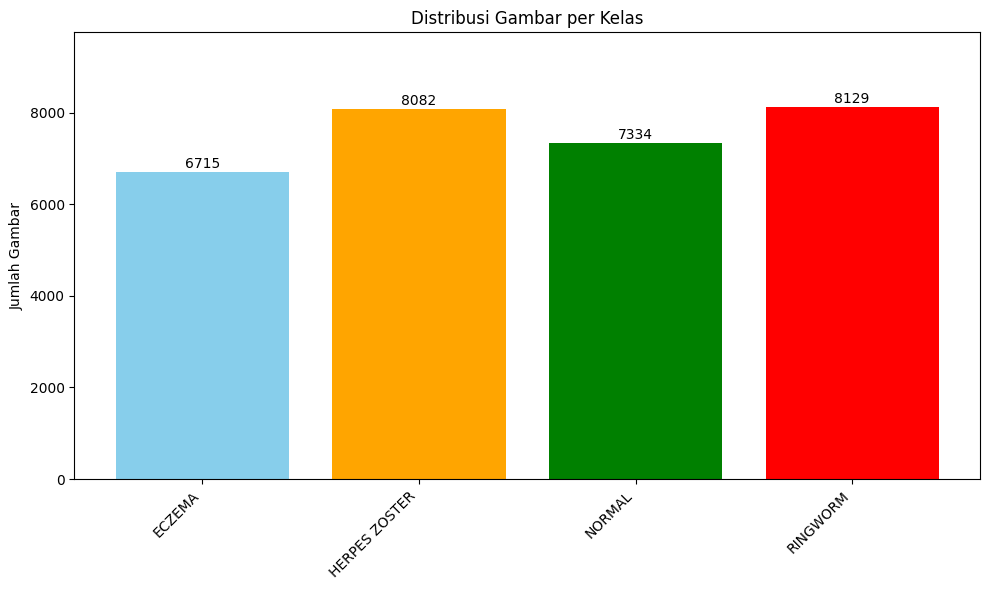

In [ ]:
classes = df_info['Class'].values
counts = df_info['Total Images'].values

plt.figure(figsize=(10,6))

bars = plt.bar(classes, counts, color=['skyblue','orange','green','red'])

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(count), ha='center', va='bottom', fontsize=10)

plt.ylabel('Jumlah Gambar')
plt.title('Distribusi Gambar per Kelas')

plt.ylim(0, max(counts) * 1.2)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

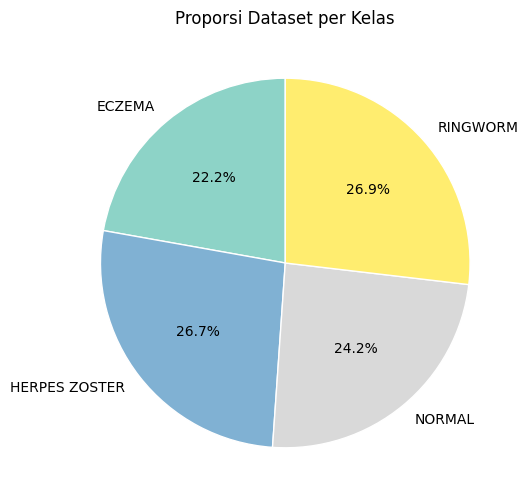

In [ ]:
class_counts = df_info.set_index('Class')['Total Images']

plt.figure(figsize=(6,6))

plt.pie(
    class_counts,
    labels=class_counts.index,
    autopct='%1.1f%%',
    colors=plt.cm.Set3(np.linspace(0, 1, len(class_counts))),
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)

plt.title("Proporsi Dataset per Kelas")
plt.show()

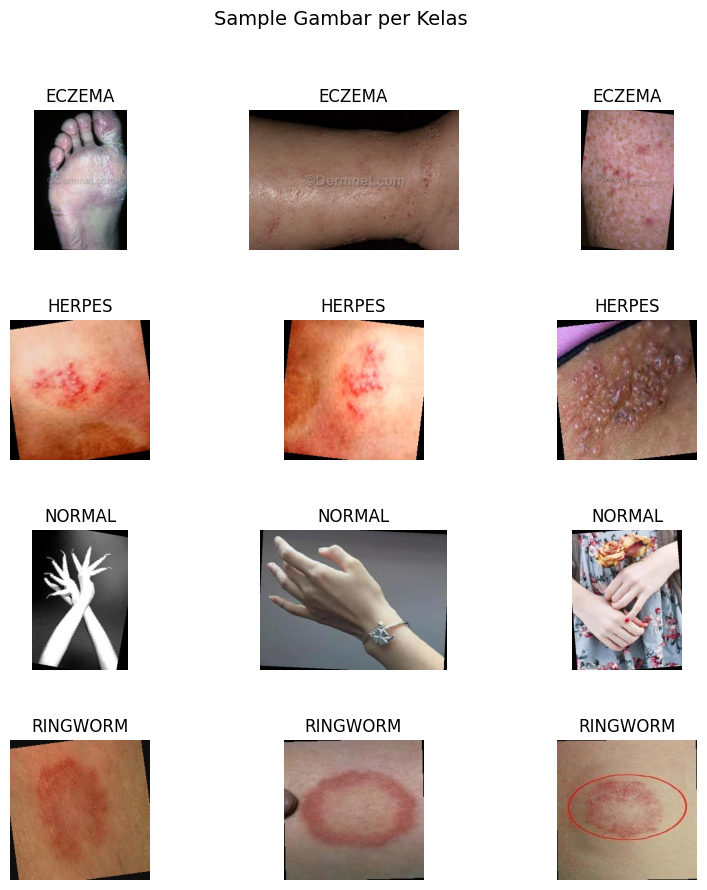

In [ ]:
df_images = pd.DataFrame([
    {
        'filepath': os.path.join(data_dir, c, img),
        'Class': c
    }
    for c in classes_dir
    for img in os.listdir(os.path.join(data_dir, c))
])

plt.figure(figsize=(10,10))

for i, cls in enumerate(classes):
    class_df = df_images[df_images['Class'] == cls]

    if not class_df.empty:
        samples = class_df.sample(min(3, len(class_df)), random_state=42)

        for j, (_, row) in enumerate(samples.iterrows()):
            plt.subplot(len(classes), 3, i*3 + j + 1)

            img = Image.open(row['filepath']).convert('RGB')
            plt.imshow(img)

            plt.title(cls.split()[0])
            plt.axis('off')

plt.suptitle("Sample Gambar per Kelas", fontsize=14)
plt.subplots_adjust(hspace=0.5)
plt.show()

### **DATA PREPROCESSING & DATA SPLITTING**



In [ ]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

In [ ]:
data_dir = "skindisease/Dataset_Klasifikasi"
full_dataset = torchvision.datasets.ImageFolder(root=data_dir)
all_paths = [p for p, _ in full_dataset.samples]
all_labels = [l for _, l in full_dataset.samples]

In [ ]:
valid_paths, valid_labels = [], []

for p, l in zip(all_paths, all_labels):
    if cv2.imread(p) is not None:
        valid_paths.append(p)
        valid_labels.append(l)

all_paths, all_labels = valid_paths, valid_labels
print("After removing broken images:", len(all_paths))

After removing broken images: 30260


In [ ]:
def hash_image(path):
    try:
        with open(path, 'rb') as f:
            return hashlib.md5(f.read()).hexdigest()
    except:
        return None

seen = set()
unique_paths, unique_labels = [], []

for p, l in zip(all_paths, all_labels):
    h = hash_image(p)
    if h and h not in seen:
        seen.add(h)
        unique_paths.append(p)
        unique_labels.append(l)

all_paths, all_labels = unique_paths, unique_labels
print("After removing duplicates:", len(all_paths))

After removing duplicates: 30151


In [ ]:
# 10% test
trainval_paths, test_paths, trainval_labels, test_labels = train_test_split(
    all_paths, all_labels,
    test_size=0.1,
    stratify=all_labels,
    random_state=SEED
)

# 70% train, 20% val
train_paths, val_paths, train_labels, val_labels = train_test_split(
    trainval_paths, trainval_labels,
    test_size=0.2222,
    stratify=trainval_labels,
    random_state=SEED
)

print("Train:", len(train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))

Train: 21105
Val: 6030
Test: 3016


In [ ]:
# CHECK DATA LEAKAGE
def get_hash_set(paths):
    hashes = set()
    for p in paths:
        h = hash_image(p)
        if h:
            hashes.add(h)
    return hashes

train_hash = get_hash_set(train_paths)
val_hash   = get_hash_set(val_paths)
test_hash  = get_hash_set(test_paths)

# Cek overlap
train_val_overlap  = train_hash.intersection(val_hash)
train_test_overlap = train_hash.intersection(test_hash)
val_test_overlap   = val_hash.intersection(test_hash)

print("DATA LEAKAGE CHECK")
print(f"Train-Val Overlap  : {len(train_val_overlap)}")
print(f"Train-Test Overlap : {len(train_test_overlap)}")
print(f"Val-Test Overlap   : {len(val_test_overlap)}")

if len(train_val_overlap) == 0 and len(train_test_overlap) == 0 and len(val_test_overlap) == 0:
    print("Tidak ada data leakage")
else:
    print("Ada data yang overlap!")

DATA LEAKAGE CHECK
Train-Val Overlap  : 0
Train-Test Overlap : 0
Val-Test Overlap   : 0
Tidak ada data leakage


### **Data Preparation**

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.3,0.3,0.3),
    transforms.RandomAutocontrast(p=0.4),
    transforms.RandomPerspective(0.4, p=0.5),
    transforms.RandomAdjustSharpness(2, p=0.4),
    transforms.GaussianBlur(3, sigma=(0.1, 2.5)),
    transforms.RandomGrayscale(0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [ ]:
class SkinDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert("RGB")
        except:
            img = Image.new("RGB", (IMG_SIZE, IMG_SIZE))

        if self.transform:
            img = self.transform(img)

        return img, self.labels[idx]

In [ ]:
train_dataset = SkinDataset(train_paths, train_labels, train_transform)
val_dataset   = SkinDataset(val_paths, val_labels, val_test_transform)
test_dataset  = SkinDataset(test_paths, test_labels, val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

### **MODEL 2 - RESNET50**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

classes = full_dataset.classes
NUM_CLASSES = len(classes)
print(f"Number of classes: {NUM_CLASSES}")
print(f"Classes: {classes}")

# Stage 1
EPOCHS_S1 = 10
LR_S1 = 1e-5
PATIENCE_S1 = 3

# Stage 2
EPOCHS_S2 = 10
LR_S2 = 1e-6
WEIGHT_DECAY_S2 = 1e-4
PATIENCE_S2 = 3

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

Using device: cuda
Number of classes: 4
Classes: ['ECZEMA', 'HERPES ZOSTER', 'NORMAL', 'RINGWORM']


In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs, patience):

    best_acc = 0
    best_wts = copy.deepcopy(model.state_dict())

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    no_improve = 0

    for epoch in range(epochs):
        start_time = time.time()

        model.train()
        train_loss, correct, total = 0, 0, 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

        train_loss /= len(train_loader.dataset)
        train_acc = correct / total

        model.eval()
        val_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)

                out = model(x)
                loss = criterion(out, y)

                val_loss += loss.item() * x.size(0)
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)

        val_loss /= len(val_loader.dataset)
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
              f"Time: {(time.time() - start_time):.2f}s")

        if scheduler:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        if val_acc > best_acc:
            best_acc = val_acc
            best_wts = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print("Early stopping")
                break

    model.load_state_dict(best_wts)
    return model, history, best_acc

In [ ]:
model = models.resnet50(weights='IMAGENET1K_V1')
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, NUM_CLASSES)
)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 176MB/s]


In [ ]:
print(">>> STAGE 1: WARM-UP CLASSIFIER <<<")

for p in model.parameters():
    p.requires_grad = False
for p in model.fc.parameters():
    p.requires_grad = True

optimizer_s1 = optim.Adam(
    model.fc.parameters(),
    lr=LR_S1
)

scheduler_s1 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_s1,
    mode='min',
    factor=0.5,
    patience=2
)

model, history1, acc1 = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer_s1,
    scheduler_s1,
    EPOCHS_S1,
    PATIENCE_S1
)

>>> STAGE 1: WARM-UP CLASSIFIER <<<
Epoch 1/10 | Train Loss: 1.0998 Acc: 0.6659 | Val Loss: 0.8044 Acc: 0.8806 | Time: 254.42s
Epoch 2/10 | Train Loss: 0.7884 Acc: 0.8307 | Val Loss: 0.6390 Acc: 0.9114 | Time: 247.36s
Epoch 3/10 | Train Loss: 0.6870 Acc: 0.8610 | Val Loss: 0.5903 Acc: 0.9156 | Time: 244.04s
Epoch 4/10 | Train Loss: 0.6408 Acc: 0.8805 | Val Loss: 0.5646 Acc: 0.9156 | Time: 245.52s
Epoch 5/10 | Train Loss: 0.6119 Acc: 0.8892 | Val Loss: 0.5449 Acc: 0.9234 | Time: 253.88s
Epoch 6/10 | Train Loss: 0.5891 Acc: 0.8999 | Val Loss: 0.5309 Acc: 0.9284 | Time: 247.59s
Epoch 7/10 | Train Loss: 0.5760 Acc: 0.9059 | Val Loss: 0.5221 Acc: 0.9335 | Time: 245.94s
Epoch 8/10 | Train Loss: 0.5665 Acc: 0.9089 | Val Loss: 0.5129 Acc: 0.9403 | Time: 248.16s
Epoch 9/10 | Train Loss: 0.5552 Acc: 0.9152 | Val Loss: 0.5018 Acc: 0.9454 | Time: 251.43s
Epoch 10/10 | Train Loss: 0.5497 Acc: 0.9187 | Val Loss: 0.5022 Acc: 0.9448 | Time: 255.96s


In [ ]:
print("\n>>> STAGE 2: FINE-TUNING (Unfreeze Last Blocks) <<<")

for p in model.layer4.parameters():
    p.requires_grad = True

optimizer_s2 = optim.Adam([
    {
        'params': [p for p in model.layer4.parameters() if p.requires_grad],
        'lr': LR_S2 / 10
    },
    {
        'params': [p for p in model.fc.parameters() if p.requires_grad],
        'lr': LR_S2
    }
], weight_decay=WEIGHT_DECAY_S2)

scheduler_s2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_s2,
    mode='min',
    factor=0.2,
    patience=2
)

model, history2, acc2 = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer_s2,
    scheduler_s2,
    epochs=EPOCHS_S2,
    patience=PATIENCE_S2
)


>>> STAGE 2: FINE-TUNING (Unfreeze Last Blocks) <<<
Epoch 1/10 | Train Loss: 0.5472 Acc: 0.9197 | Val Loss: 0.4923 Acc: 0.9498 | Time: 260.34s
Epoch 2/10 | Train Loss: 0.5400 Acc: 0.9231 | Val Loss: 0.4937 Acc: 0.9491 | Time: 264.66s
Epoch 3/10 | Train Loss: 0.5328 Acc: 0.9272 | Val Loss: 0.4794 Acc: 0.9567 | Time: 258.88s
Epoch 4/10 | Train Loss: 0.5246 Acc: 0.9329 | Val Loss: 0.4807 Acc: 0.9556 | Time: 258.74s
Epoch 5/10 | Train Loss: 0.5183 Acc: 0.9366 | Val Loss: 0.4815 Acc: 0.9557 | Time: 256.74s
Epoch 6/10 | Train Loss: 0.5147 Acc: 0.9355 | Val Loss: 0.4776 Acc: 0.9552 | Time: 258.93s
Early stopping


In [ ]:
from torchinfo import summary
summary(model, input_size=(1, 3, 224, 224), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 4]                    --
├─Conv2d: 1-1                            [1, 64, 112, 112]         (9,408)
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         (128)
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 256, 56, 56]          --
│    └─Bottleneck: 2-1                   [1, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           (4,096)
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           (128)
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           (36,864)
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           (128)
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]    

### **EVALUATION**

In [ ]:
print("\n" + "="*65)
print("  >>> EVALUATION (TEST SET) <<<")
print("="*65)

model.eval()
all_preds_test, all_targets_test = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds_test.extend(predicted.cpu().numpy())
        all_targets_test.extend(labels.cpu().numpy())

correct = sum(p == t for p, t in zip(all_preds_test, all_targets_test))
test_acc = correct / len(all_targets_test) * 100
print(f"Test Accuracy: {test_acc:.2f}%")


  >>> EVALUATION (TEST SET) <<<
Test Accuracy: 96.05%


In [ ]:
print("\nCLASSIFICATION REPORT")
print(classification_report(all_targets_test, all_preds_test, target_names=classes))


CLASSIFICATION REPORT
               precision    recall  f1-score   support

       ECZEMA       0.96      0.98      0.97       661
HERPES ZOSTER       0.97      0.93      0.95       808
       NORMAL       0.99      0.99      0.99       734
     RINGWORM       0.93      0.94      0.94       813

     accuracy                           0.96      3016
    macro avg       0.96      0.96      0.96      3016
 weighted avg       0.96      0.96      0.96      3016



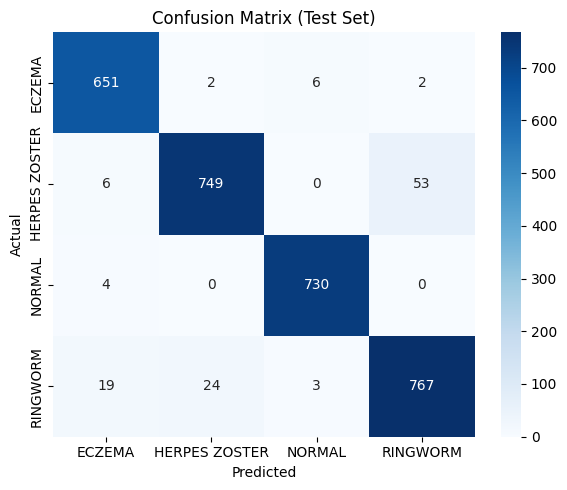

In [ ]:
cm = confusion_matrix(all_targets_test, all_preds_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

In [ ]:
print("AKURASI PER KELAS")
class_acc = cm.diagonal() / cm.sum(axis=1)
for cls, acc in zip(classes, class_acc):
    print(f"  {cls:<15} : {acc*100:.2f}%")

AKURASI PER KELAS
  ECZEMA          : 98.49%
  HERPES ZOSTER   : 92.70%
  NORMAL          : 99.46%
  RINGWORM        : 94.34%


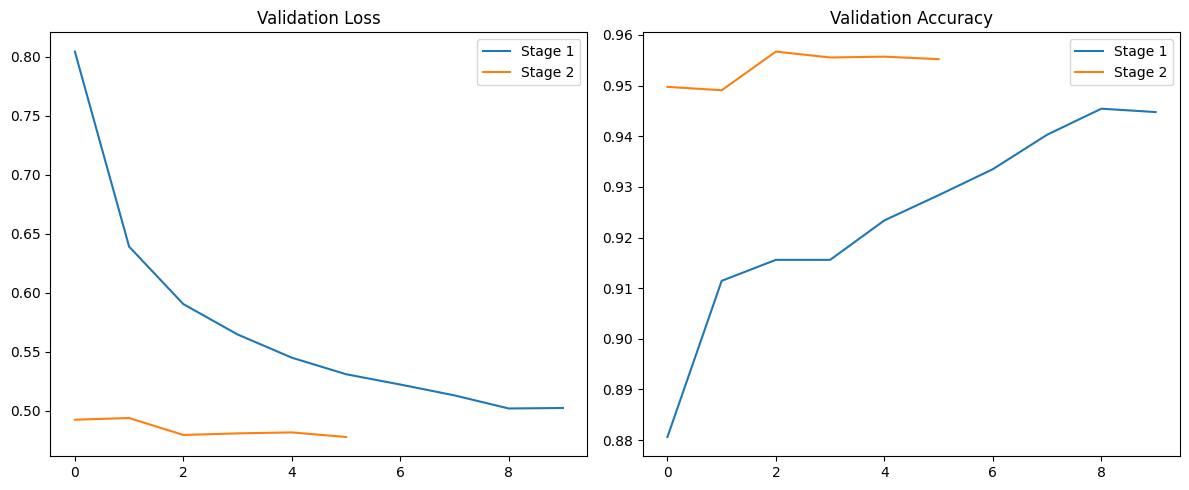

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history1['val_loss'], label='Stage 1')
plt.plot(history2['val_loss'], label='Stage 2')
plt.title("Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history1['val_acc'], label='Stage 1')
plt.plot(history2['val_acc'], label='Stage 2')
plt.title("Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*65)
print("  >>> MODEL COMPARISON <<<")
print("="*65)
print(f"  Stage 1 Best Val Accuracy : {acc1:.4f}")
print(f"  Stage 2 Best Val Accuracy : {acc2:.4f}")


  >>> MODEL COMPARISON <<<
  Stage 1 Best Val Accuracy : 0.9454
  Stage 2 Best Val Accuracy : 0.9567


### **MODEL SAVING**

In [ ]:
FINAL_MODEL_PATH = "resnet50_skin_disease_finetuned.pth"

torch.save({
    'model_state_dict': model.state_dict(),
    'classes': classes,
    'stage1_acc': acc1,
    'stage2_acc': acc2
}, FINAL_MODEL_PATH)

print(f"Model fine-tuned disimpan di: {FINAL_MODEL_PATH}")

Model fine-tuned disimpan di: resnet50_skin_disease_finetuned.pth


### **CROSS VALIDATION**

In [ ]:
k_folds = 3
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=SEED)

cv_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(trainval_paths, trainval_labels)):

    print("\n" + "="*65)
    print(f"  >>> FOLD {fold+1} / {k_folds} <<<")
    print("="*65)

    train_paths_fold  = [trainval_paths[i] for i in train_idx]
    val_paths_fold    = [trainval_paths[i] for i in val_idx]
    train_labels_fold = [trainval_labels[i] for i in train_idx]
    val_labels_fold   = [trainval_labels[i] for i in val_idx]

    fold_train_dataset = SkinDataset(train_paths_fold, train_labels_fold, train_transform)
    fold_val_dataset   = SkinDataset(val_paths_fold, val_labels_fold, val_test_transform)

    fold_train_loader = DataLoader(
        fold_train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )
    fold_val_loader = DataLoader(
        fold_val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    print(f"  Train size : {len(fold_train_dataset)} | Val size : {len(fold_val_dataset)}")

    model_cv = models.resnet50(weights='IMAGENET1K_V1')
    in_features = model_cv.fc.in_features
    model_cv.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, NUM_CLASSES)
    )
    model_cv = model_cv.to(device)

    # Stage 1
    print("\n" + "="*65)
    print(f"  >>> FOLD {fold+1} | STAGE 1: WARM-UP CLASSIFIER <<<")
    print("="*65)

    for p in model_cv.parameters():
        p.requires_grad = False
    for p in model_cv.fc.parameters():
        p.requires_grad = True

    optimizer_s1 = optim.Adam(
        model_cv.fc.parameters(),
        lr=LR_S1
    )

    scheduler_s1 = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_s1,
        mode='min',
        factor=0.5,
        patience=2
    )

    model_cv, _, _ = train_model(
        model_cv,
        fold_train_loader,
        fold_val_loader,
        criterion,
        optimizer_s1,
        scheduler_s1,
        epochs=5,
        patience=2
    )

    # Stage 2
    print("\n" + "="*65)
    print(f"  >>> FOLD {fold+1} | STAGE 2: FINE-TUNING (Unfreeze Last Blocks) <<<")
    print("="*65)

    for p in model_cv.layer4.parameters():
        p.requires_grad = True

    optimizer_s2 = optim.Adam([
        {
            'params': [p for p in model_cv.layer4.parameters() if p.requires_grad],
            'lr': LR_S2 / 10
        },
        {
            'params': [p for p in model_cv.fc.parameters() if p.requires_grad],
            'lr': LR_S2
        }
    ], weight_decay=WEIGHT_DECAY_S2)

    scheduler_s2 = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_s2,
        mode='min',
        factor=0.2,
        patience=2
    )

    model_cv, _, fold_acc = train_model(
        model_cv,
        fold_train_loader,
        fold_val_loader,
        criterion,
        optimizer_s2,
        scheduler_s2,
        epochs=5,
        patience=2
    )

    print("\n" + "="*65)
    print(f"  Fold {fold+1} Best Val Accuracy : {fold_acc:.4f}  ({fold_acc*100:.2f}%)")
    print("="*65)

    cv_results.append(fold_acc)


  >>> FOLD 1 / 3 <<<
  Train size : 18090 | Val size : 9045

  >>> FOLD 1 | STAGE 1: WARM-UP CLASSIFIER <<<
Epoch 1/5 | Train Loss: 1.1425 Acc: 0.6350 | Val Loss: 0.8719 Acc: 0.8570 | Time: 240.85s
Epoch 2/5 | Train Loss: 0.8454 Acc: 0.8135 | Val Loss: 0.6933 Acc: 0.8989 | Time: 236.26s
Epoch 3/5 | Train Loss: 0.7244 Acc: 0.8504 | Val Loss: 0.6181 Acc: 0.9081 | Time: 230.62s
Epoch 4/5 | Train Loss: 0.6666 Acc: 0.8704 | Val Loss: 0.5874 Acc: 0.9128 | Time: 230.36s
Epoch 5/5 | Train Loss: 0.6340 Acc: 0.8803 | Val Loss: 0.5562 Acc: 0.9239 | Time: 228.66s

  >>> FOLD 1 | STAGE 2: FINE-TUNING (Unfreeze Last Blocks) <<<
Epoch 1/5 | Train Loss: 0.6146 Acc: 0.8888 | Val Loss: 0.5458 Acc: 0.9263 | Time: 237.18s
Epoch 2/5 | Train Loss: 0.5999 Acc: 0.9002 | Val Loss: 0.5271 Acc: 0.9372 | Time: 233.11s
Epoch 3/5 | Train Loss: 0.5914 Acc: 0.9007 | Val Loss: 0.5346 Acc: 0.9331 | Time: 232.13s
Epoch 4/5 | Train Loss: 0.5783 Acc: 0.9066 | Val Loss: 0.5239 Acc: 0.9364 | Time: 236.11s
Early stopping

 

In [ ]:
cv_results_clean = [x.cpu().item() if hasattr(x, 'cpu') else x for x in cv_results]

print(f"{'='*50}")
print("       CROSS VALIDATION RESULT")
print(f"{'='*50}")

for i, acc in enumerate(cv_results_clean):
    print(f"  Fold {i+1} Accuracy : {acc:.4f} ({acc*100:.2f}%)")

print(f"{'─'*50}")
print(f"  Mean Accuracy    : {np.mean(cv_results_clean):.4f} ({np.mean(cv_results_clean)*100:.2f}%)")
print(f"  Std Deviation    : {np.std(cv_results_clean):.4f}")
print(f"{'='*50}")

       CROSS VALIDATION RESULT
  Fold 1 Accuracy : 0.9372 (93.72%)
  Fold 2 Accuracy : 0.9417 (94.17%)
  Fold 3 Accuracy : 0.9434 (94.34%)
──────────────────────────────────────────────────
  Mean Accuracy    : 0.9408 (94.08%)
  Std Deviation    : 0.0026


### **INFERENCE (DATASET EKSTERNAL - GOOGLE**

Saving eczema_google9.jpg to eczema_google9.jpg


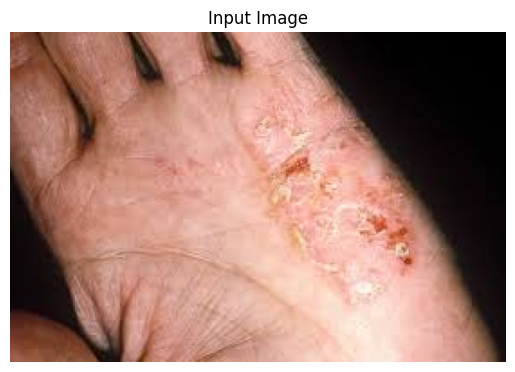

Prediksi: ECZEMA
Confidence: 91.24%


In [ ]:
uploaded = files.upload()

model.eval()

for img_name in uploaded.keys():
    img = Image.open(img_name).convert("RGB")

    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    img_tensor = val_test_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(output, dim=1).item()

    print("Prediksi:", classes[pred])
    print("Confidence:", f"{probs[0][pred].item()*100:.2f}%")

Saving FU-ringworm_google6.jpg to FU-ringworm_google6.jpg


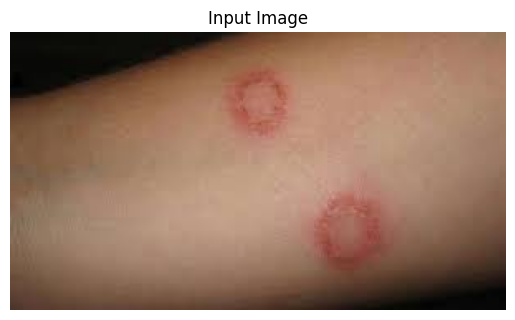

Prediksi: RINGWORM
Confidence: 75.91%


In [ ]:
uploaded = files.upload()

model.eval()

for img_name in uploaded.keys():
    img = Image.open(img_name).convert("RGB")

    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    img_tensor = val_test_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(output, dim=1).item()

    print("Prediksi:", classes[pred])
    print("Confidence:", f"{probs[0][pred].item()*100:.2f}%")

Saving google8.jpg to google8.jpg


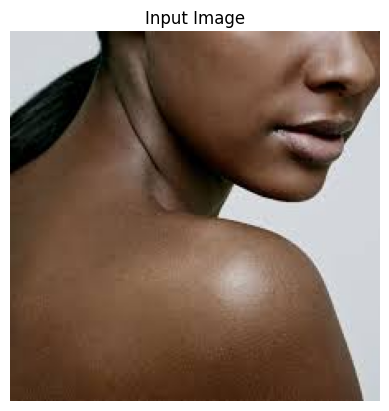

Prediksi: NORMAL
Confidence: 72.75%


In [ ]:
uploaded = files.upload()

model.eval()

for img_name in uploaded.keys():
    img = Image.open(img_name).convert("RGB")

    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    img_tensor = val_test_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(output, dim=1).item()

    print("Prediksi:", classes[pred])
    print("Confidence:", f"{probs[0][pred].item()*100:.2f}%")

Saving VI_shingles_google9.jpg to VI_shingles_google9.jpg


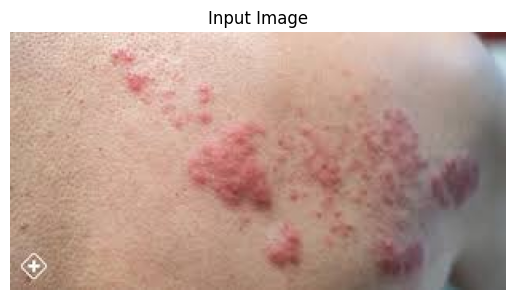

Prediksi: HERPES ZOSTER
Confidence: 59.04%


In [ ]:
uploaded = files.upload()

model.eval()

for img_name in uploaded.keys():
    img = Image.open(img_name).convert("RGB")

    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    img_tensor = val_test_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(output, dim=1).item()

    print("Prediksi:", classes[pred])
    print("Confidence:", f"{probs[0][pred].item()*100:.2f}%")

### **INFERENCE (DATASET)**

Saving aug_1952_0210.jpg to aug_1952_0210.jpg


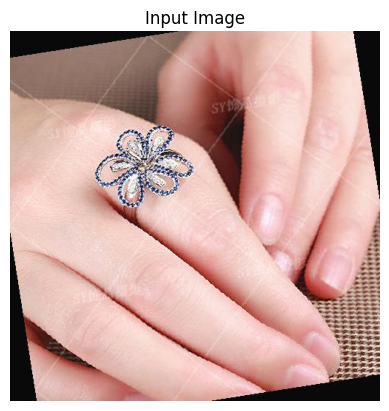

Prediksi: NORMAL
Confidence: 77.99%


In [ ]:
uploaded = files.upload()

model.eval()

for img_name in uploaded.keys():
    img = Image.open(img_name).convert("RGB")

    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    img_tensor = val_test_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(output, dim=1).item()

    print("Prediksi:", classes[pred])
    print("Confidence:", f"{probs[0][pred].item()*100:.2f}%")

Saving 70_FU-ringworm (8).jpeg to 70_FU-ringworm (8).jpeg


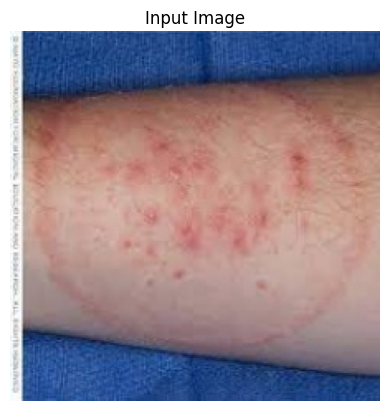

Prediksi: RINGWORM
Confidence: 50.52%


In [ ]:
uploaded = files.upload()

model.eval()

for img_name in uploaded.keys():
    img = Image.open(img_name).convert("RGB")

    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    img_tensor = val_test_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(output, dim=1).item()

    print("Prediksi:", classes[pred])
    print("Confidence:", f"{probs[0][pred].item()*100:.2f}%")

Saving eczema-fingertips-41.jpg to eczema-fingertips-41.jpg


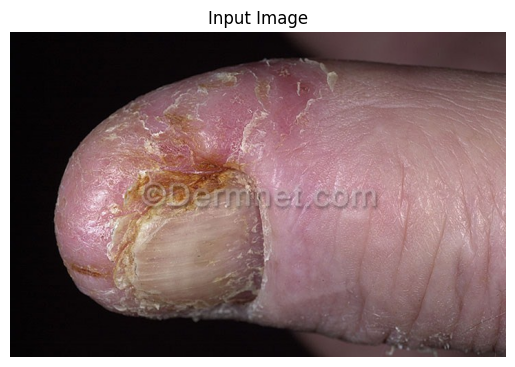

Prediksi: ECZEMA
Confidence: 95.29%


In [ ]:
uploaded = files.upload()

model.eval()

for img_name in uploaded.keys():
    img = Image.open(img_name).convert("RGB")

    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    img_tensor = val_test_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(output, dim=1).item()

    print("Prediksi:", classes[pred])
    print("Confidence:", f"{probs[0][pred].item()*100:.2f}%")

Saving aug_690_148_VI-shingles (9).jpg to aug_690_148_VI-shingles (9).jpg


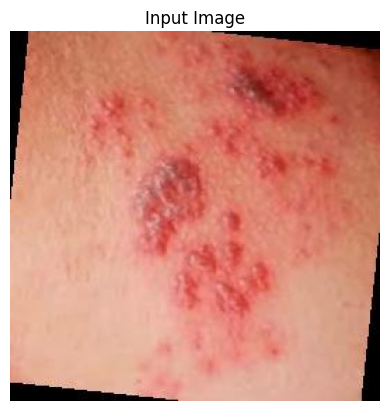

Prediksi: HERPES ZOSTER
Confidence: 66.64%


In [ ]:
uploaded = files.upload()

model.eval()

for img_name in uploaded.keys():
    img = Image.open(img_name).convert("RGB")

    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    img_tensor = val_test_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(output, dim=1).item()

    print("Prediksi:", classes[pred])
    print("Confidence:", f"{probs[0][pred].item()*100:.2f}%")